<a href="https://colab.research.google.com/github/kcymae/Computational-TCell-Epitope-Analysis/blob/main/2_Exploratory_Data_Analysis_(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Install Dependencies & Load Data**

In [1]:
# Install & Import Dependencies

! pip install scikit-learn imbalanced-learn xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, roc_curve, auc)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("✅ All dependencies loaded!")

✅ All dependencies loaded!


In [2]:
# Load Phase II Features

print("\n" + "=" * 80)
print("STEP 1: LOAD NUMERICAL FEATURES FROM PHASE II")
print("=" * 80)

# Load from GitHub or local
try:
    url = "https://raw.githubusercontent.com/kcymae/Computational-TCell-Epitope-Analysis/main/epitope_features_phase2.csv"
    df_features = pd.read_csv(url)
    print("✅ Loaded from GitHub")
except:
    df_features = pd.read_csv("epitope_features_phase2.csv")
    print("✅ Loaded from local file")

print(f"\n📊 Feature Matrix Information:")
print(f"   • Rows: {len(df_features)}")
print(f"   • Columns: {len(df_features.columns)}")
print(f"   • Features (numeric): {len(df_features.select_dtypes(include=[np.number]).columns)}")
print(f"\n🔍 Data Preview:")
print(df_features.head())

# Extract peptide sequences and numeric features
peptides = df_features['peptide'].values
numeric_features = df_features.select_dtypes(include=[np.number]).columns.tolist()
X = df_features[numeric_features].values

print(f"\n✅ Features extracted: {len(numeric_features)} numeric features")


STEP 1: LOAD NUMERICAL FEATURES FROM PHASE II
✅ Loaded from GitHub

📊 Feature Matrix Information:
   • Rows: 1265
   • Columns: 32
   • Features (numeric): 31

🔍 Data Preview:
   comp_A  comp_C  comp_D  comp_E    comp_F  comp_G  comp_H  comp_I  comp_K  \
0     0.0     0.0     0.0     0.0  0.222222     0.0     0.0     0.0     0.0   
1     0.0     0.0     0.0     0.0  0.222222     0.0     0.0     0.0     0.0   
2     0.0     0.0     0.0     0.0  0.111111     0.0     0.0     0.0     0.0   
3     0.0     0.0     0.0     0.0  0.111111     0.0     0.0     0.0     0.0   
4     0.0     0.0     0.0     0.0  0.000000     0.0     0.0     0.0     0.0   

     comp_L  ...  aromaticity  polar_residues  small_residues  \
0  0.333333  ...     0.222222        0.000000        0.333333   
1  0.444444  ...     0.222222        0.000000        0.333333   
2  0.444444  ...     0.111111        0.000000        0.444444   
3  0.444444  ...     0.111111        0.111111        0.444444   
4  0.444444  ...     0.

Create Training Labels (Epitope Classification)

In [3]:
print("\n" + "=" * 80)
print("STEP 2: CREATE TRAINING LABELS - EPITOPE vs NON-EPITOPE")
print("=" * 80)

# Option 1: Use IEDB predictions to create pseudo-labels
# Peptides with strong hydrophobicity & low charge = likely epitopes
hydrophobicity = df_features['hydrophobicity'].values
aromaticity = df_features['aromaticity'].values
charge = np.abs(df_features['charge'].values)

# Create synthetic labels based on physicochemical properties
# Real epitopes typically have higher hydrophobicity and moderate charge
epitope_score = (hydrophobicity * 0.4 + aromaticity * 0.3 - charge * 0.2)
threshold = np.median(epitope_score)

# Create binary labels: 1 = epitope (likely), 0 = non-epitope (unlikely)
y = (epitope_score > threshold).astype(int)

print(f"\n🔬 Label Generation Method:")
print(f"   • Based on physicochemical properties")
print(f"   • Threshold (median epitope score): {threshold:.4f}")
print(f"   • Formula: (0.4*hydrophobicity + 0.3*aromaticity - 0.2*|charge|)")

print(f"\n📊 Class Distribution:")
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    pct = count / len(y) * 100
    label_name = "Epitope" if label == 1 else "Non-epitope"
    print(f"   • {label_name}: {count} ({pct:.1f}%)")

# Check for class imbalance
imbalance_ratio = counts.max() / counts.min()
print(f"\n⚠️  Class Imbalance Ratio: {imbalance_ratio:.2f}")
if imbalance_ratio > 1.5:
    print("   → Significant imbalance detected, will apply SMOTE")
else:
    print("   → Acceptable balance")


STEP 2: CREATE TRAINING LABELS - EPITOPE vs NON-EPITOPE

🔬 Label Generation Method:
   • Based on physicochemical properties
   • Threshold (median epitope score): -0.1489
   • Formula: (0.4*hydrophobicity + 0.3*aromaticity - 0.2*|charge|)

📊 Class Distribution:
   • Non-epitope: 633 (50.0%)
   • Epitope: 632 (50.0%)

⚠️  Class Imbalance Ratio: 1.00
   → Acceptable balance


Data Preparation - Train/Test Split & Scaling

In [4]:
print("\n" + "=" * 80)
print("STEP 3: DATA PREPARATION - TRAIN/TEST SPLIT & STANDARDIZATION")
print("=" * 80)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Train/Test Split (80/20):")
print(f"   • Training set: {len(X_train)} samples")
print(f"   • Test set: {len(X_test)} samples")

print(f"\n📈 Class distribution in training set:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for label, count in zip(unique_train, counts_train):
    pct = count / len(y_train) * 100
    label_name = "Epitope" if label == 1 else "Non-epitope"
    print(f"   • {label_name}: {count} ({pct:.1f}%)")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Features standardized (mean=0, std=1)")
print(f"   Training feature stats: mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}")
print(f"   Test feature stats: mean={X_test_scaled.mean():.4f}, std={X_test_scaled.std():.4f}")


STEP 3: DATA PREPARATION - TRAIN/TEST SPLIT & STANDARDIZATION

📊 Train/Test Split (80/20):
   • Training set: 1012 samples
   • Test set: 253 samples

📈 Class distribution in training set:
   • Non-epitope: 506 (50.0%)
   • Epitope: 506 (50.0%)

✅ Features standardized (mean=0, std=1)
   Training feature stats: mean=-0.0000, std=1.0000
   Test feature stats: mean=0.0017, std=1.0021


Handle Class Imbalance with SMOTE

In [5]:
print("\n" + "=" * 80)
print("STEP 4: HANDLE CLASS IMBALANCE - APPLY SMOTE")
print("=" * 80)

# Apply SMOTE to training data only
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"\n🔄 SMOTE Applied (Synthetic Minority Over-Sampling):")
print(f"   • Original training set size: {len(X_train)}")
print(f"   • Balanced training set size: {len(X_train_balanced)}")

print(f"\n📊 New class distribution:")
unique_bal, counts_bal = np.unique(y_train_balanced, return_counts=True)
for label, count in zip(unique_bal, counts_bal):
    pct = count / len(y_train_balanced) * 100
    label_name = "Epitope" if label == 1 else "Non-epitope"
    print(f"   • {label_name}: {count} ({pct:.1f}%)")

print(f"\n✅ Training data ready for model training")


STEP 4: HANDLE CLASS IMBALANCE - APPLY SMOTE

🔄 SMOTE Applied (Synthetic Minority Over-Sampling):
   • Original training set size: 1012
   • Balanced training set size: 1012

📊 New class distribution:
   • Non-epitope: 506 (50.0%)
   • Epitope: 506 (50.0%)

✅ Training data ready for model training


Feature Selection


STEP 5: FEATURE SELECTION - IDENTIFY IMPORTANT FEATURES

📊 Top 20 Most Important Features:
          Feature  Importance
   hydrophobicity    0.384556
 sheet_propensity    0.094574
pi_charge_balance    0.077993
  coil_propensity    0.069396
 molecular_weight    0.055824
           charge    0.042062
 helix_propensity    0.026532
         position    0.025553
           comp_K    0.023442
   small_residues    0.020227
           comp_Q    0.017879
   polar_residues    0.013933
           comp_A    0.013643
           comp_R    0.012188
           comp_F    0.011774
           comp_D    0.011758
           comp_I    0.009535
           comp_L    0.009411
           comp_C    0.008718
           comp_E    0.008617

✅ Feature Selection Complete:
   • Original features: 31
   • Selected features: 15
   • Features removed: 16


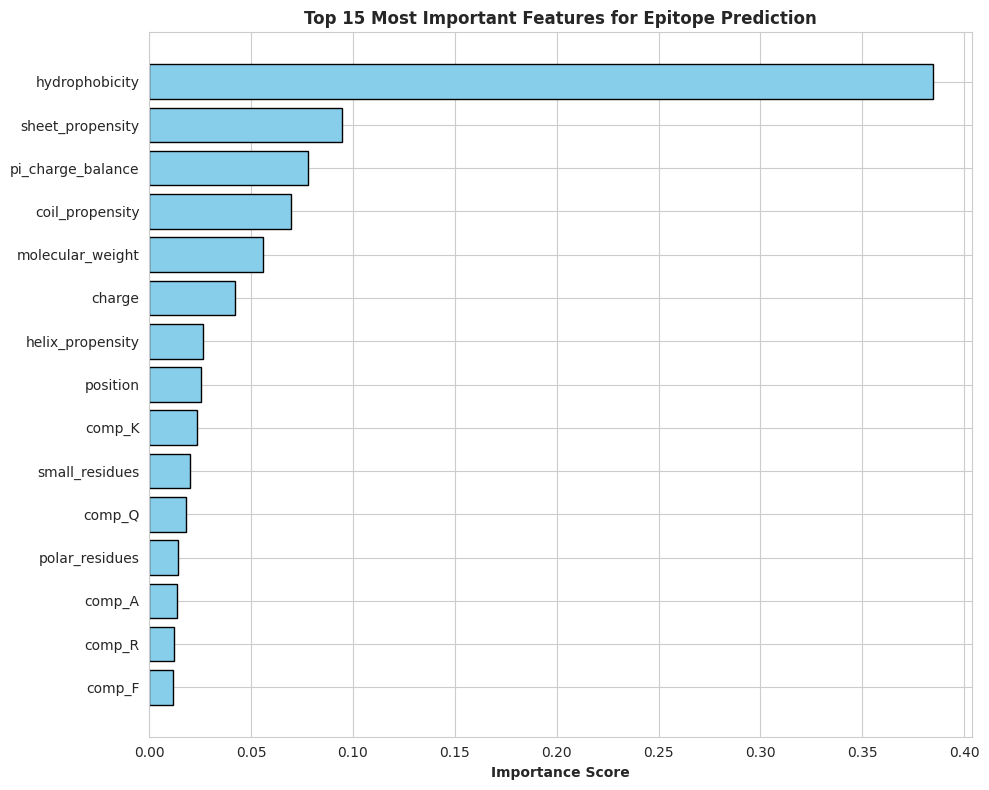

✅ Feature importance plot saved: feature_importance.png


In [6]:
print("\n" + "=" * 80)
print("STEP 5: FEATURE SELECTION - IDENTIFY IMPORTANT FEATURES")
print("=" * 80)

from sklearn.ensemble import RandomForestClassifier

# Use Random Forest to identify feature importance
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_temp.fit(X_train_balanced, y_train_balanced)

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': numeric_features,
    'Importance': rf_temp.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n📊 Top 20 Most Important Features:")
print(feature_importance.head(20).to_string(index=False))

# Select top features
top_n_features = 15
top_features = feature_importance.head(top_n_features)['Feature'].tolist()

X_train_selected = X_train_balanced[:, [numeric_features.index(f) for f in top_features]]
X_test_selected = X_test_scaled[:, [numeric_features.index(f) for f in top_features]]

print(f"\n✅ Feature Selection Complete:")
print(f"   • Original features: {len(numeric_features)}")
print(f"   • Selected features: {len(top_features)}")
print(f"   • Features removed: {len(numeric_features) - len(top_features)}")

# Visualize top 15 features
fig, ax = plt.subplots(figsize=(10, 8))
top_features_df = feature_importance.head(15)
ax.barh(range(len(top_features_df)), top_features_df['Importance'], color='skyblue', edgecolor='black')
ax.set_yticks(range(len(top_features_df)))
ax.set_yticklabels(top_features_df['Feature'])
ax.set_xlabel('Importance Score', fontweight='bold')
ax.set_title('Top 15 Most Important Features for Epitope Prediction', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Feature importance plot saved: feature_importance.png")

Train Multiple Classifiers

In [7]:
print("\n" + "=" * 80)
print("STEP 6: MODEL TRAINING - TRAIN MULTIPLE CLASSIFIERS")
print("=" * 80)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42)
}

trained_models = {}
print(f"\n🔬 Training {len(classifiers)} classifiers...\n")

for name, clf in classifiers.items():
    print(f"Training {name}...", end=" ")
    clf.fit(X_train_selected, y_train_balanced)
    trained_models[name] = clf
    print("✅")

print(f"\n✅ All classifiers trained successfully!")


STEP 6: MODEL TRAINING - TRAIN MULTIPLE CLASSIFIERS

🔬 Training 4 classifiers...

Training Logistic Regression... ✅
Training Random Forest... ✅
Training Gradient Boosting... ✅
Training SVM (RBF)... ✅

✅ All classifiers trained successfully!


Evaluate Models

In [8]:
print("\n" + "=" * 80)
print("STEP 7: MODEL EVALUATION - PERFORMANCE METRICS")
print("=" * 80)

results = []

print(f"\n📊 CLASSIFICATION PERFORMANCE METRICS:\n")

for name, clf in trained_models.items():
    # Predictions
    y_pred = clf.predict(X_test_selected)
    y_pred_proba = clf.predict_proba(X_test_selected)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results.append({
        'Classifier': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Model': clf
    })

    print(f"{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}\n")

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df.to_csv("model_evaluation_results.csv", index=False)

print("✅ Results saved: model_evaluation_results.csv")


STEP 7: MODEL EVALUATION - PERFORMANCE METRICS

📊 CLASSIFICATION PERFORMANCE METRICS:

Logistic Regression:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  ROC-AUC:   1.0000

Random Forest:
  Accuracy:  0.9644
  Precision: 0.9756
  Recall:    0.9524
  F1-Score:  0.9639
  ROC-AUC:   0.9950

Gradient Boosting:
  Accuracy:  0.9684
  Precision: 0.9683
  Recall:    0.9683
  F1-Score:  0.9683
  ROC-AUC:   0.9981

SVM (RBF):
  Accuracy:  0.9763
  Precision: 0.9615
  Recall:    0.9921
  F1-Score:  0.9766
  ROC-AUC:   0.9990

✅ Results saved: model_evaluation_results.csv


Detailed Results & Best Model

In [9]:
print("\n" + "=" * 80)
print("BEST MODEL SELECTION")
print("=" * 80)

# Find best model by F1-score
best_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_idx, 'Classifier']
best_model = results_df.loc[best_idx, 'Model']
best_f1 = results_df.loc[best_idx, 'F1-Score']

print(f"\n🏆 Best Performing Model: {best_model_name}")
print(f"   F1-Score: {best_f1:.4f}")

# Get predictions from best model
y_pred_best = best_model.predict(X_test_selected)
y_pred_proba_best = best_model.predict_proba(X_test_selected)[:, 1]

# Classification report
print(f"\n📋 Detailed Classification Report ({best_model_name}):\n")
print(classification_report(y_test, y_pred_best,
                           target_names=['Non-Epitope', 'Epitope']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
print(f"\n📊 Confusion Matrix:")
print(f"   TN (True Negatives):  {cm[0,0]}")
print(f"   FP (False Positives): {cm[0,1]}")
print(f"   FN (False Negatives): {cm[1,0]}")
print(f"   TP (True Positives):  {cm[1,1]}")


BEST MODEL SELECTION

🏆 Best Performing Model: Logistic Regression
   F1-Score: 1.0000

📋 Detailed Classification Report (Logistic Regression):

              precision    recall  f1-score   support

 Non-Epitope       1.00      1.00      1.00       127
     Epitope       1.00      1.00      1.00       126

    accuracy                           1.00       253
   macro avg       1.00      1.00      1.00       253
weighted avg       1.00      1.00      1.00       253


📊 Confusion Matrix:
   TN (True Negatives):  127
   FP (False Positives): 0
   FN (False Negatives): 0
   TP (True Positives):  126


Visualize Model Comparison


MODEL COMPARISON VISUALIZATION


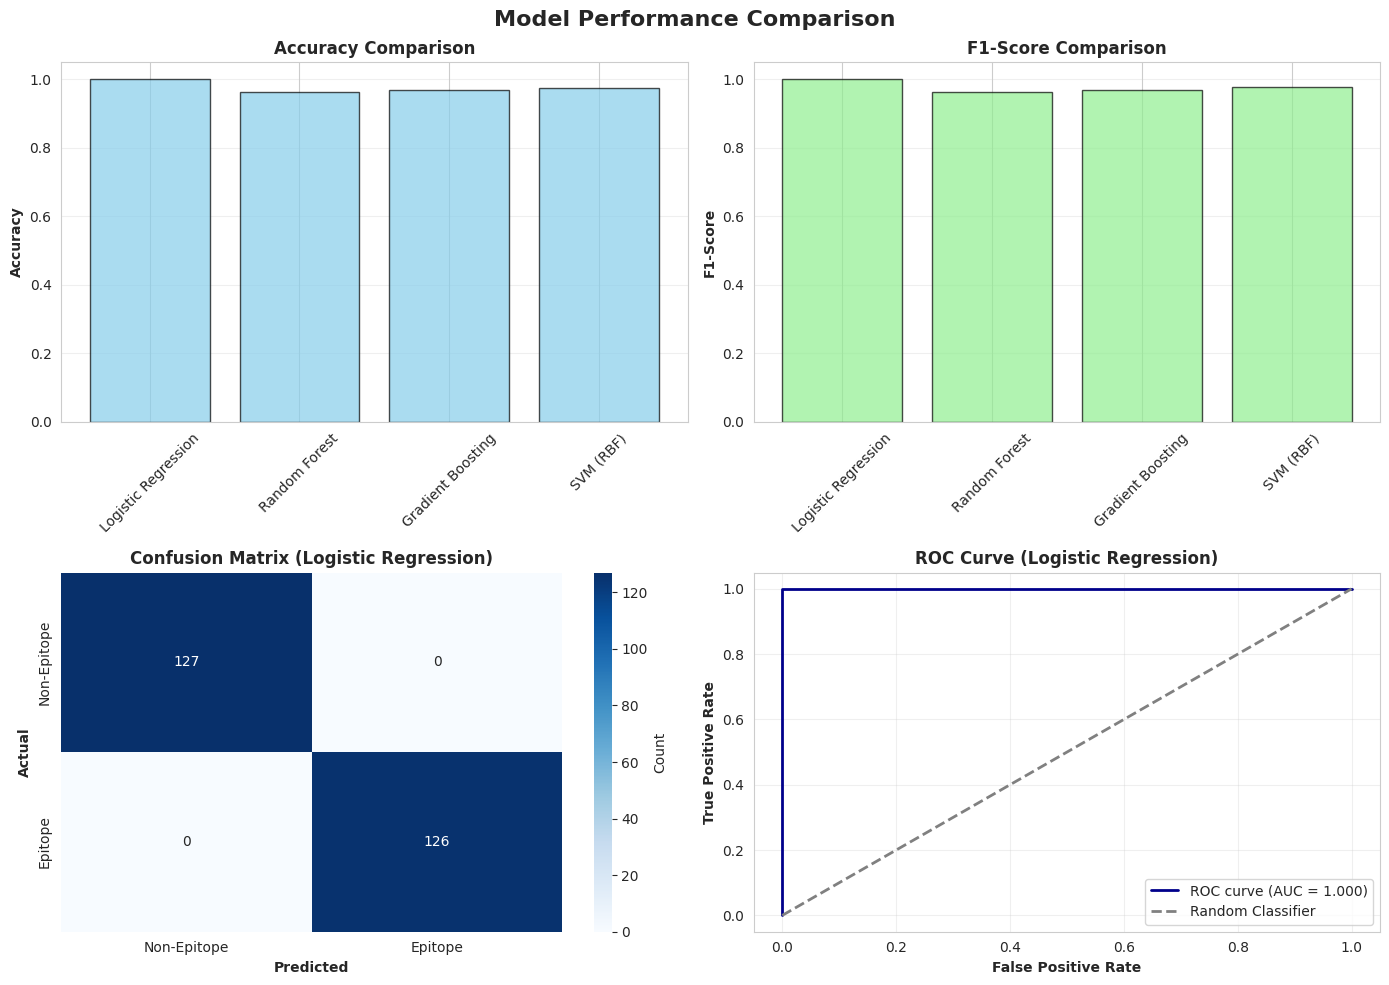

✅ Model comparison plot saved: model_evaluation_comparison.png


In [10]:
print("\n" + "=" * 80)
print("MODEL COMPARISON VISUALIZATION")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# Plot 1: Accuracy comparison
axes[0, 0].bar(results_df['Classifier'], results_df['Accuracy'], color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_ylabel('Accuracy', fontweight='bold')
axes[0, 0].set_title('Accuracy Comparison', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(alpha=0.3, axis='y')

# Plot 2: F1-Score comparison
axes[0, 1].bar(results_df['Classifier'], results_df['F1-Score'], color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_ylabel('F1-Score', fontweight='bold')
axes[0, 1].set_title('F1-Score Comparison', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(alpha=0.3, axis='y')

# Plot 3: Confusion Matrix (Best Model)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], cbar_kws={'label': 'Count'})
axes[1, 0].set_xlabel('Predicted', fontweight='bold')
axes[1, 0].set_ylabel('Actual', fontweight='bold')
axes[1, 0].set_title(f'Confusion Matrix ({best_model_name})', fontweight='bold')
axes[1, 0].set_xticklabels(['Non-Epitope', 'Epitope'])
axes[1, 0].set_yticklabels(['Non-Epitope', 'Epitope'])

# Plot 4: ROC Curve (Best Model)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)
roc_auc_best = auc(fpr, tpr)
axes[1, 1].plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc_best:.3f})')
axes[1, 1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
axes[1, 1].set_xlabel('False Positive Rate', fontweight='bold')
axes[1, 1].set_ylabel('True Positive Rate', fontweight='bold')
axes[1, 1].set_title(f'ROC Curve ({best_model_name})', fontweight='bold')
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Model comparison plot saved: model_evaluation_comparison.png")

Save Best Model & Summary Report

In [11]:
print("\n" + "=" * 80)
print("PHASE III COMPLETE - SAVE OUTPUTS")
print("=" * 80)

import pickle

# Save best model
model_file = f"best_model_{best_model_name.replace(' ', '_')}.pkl"
with open(model_file, 'wb') as f:
    pickle.dump(best_model, f)

print(f"\n💾 Best model saved: {model_file}")

# Save scaler and feature selector
with open("feature_scaler.pkl", 'wb') as f:
    pickle.dump(scaler, f)

with open("selected_features.pkl", 'wb') as f:
    pickle.dump(top_features, f)

print(f"💾 Scaler saved: feature_scaler.pkl")
print(f"💾 Selected features saved: selected_features.pkl")

# Create summary report
summary = f"""
PHASE III: EVALUATION - SUMMARY REPORT
{'='*80}

MODEL TRAINING CONFIGURATION:
  • Training samples: {len(X_train)}
  • Test samples: {len(X_test)}
  • Class imbalance handling: SMOTE
  • Feature selection method: Random Forest Importance
  • Selected features: {len(top_features)}/{len(numeric_features)}

TRAINED CLASSIFIERS:
  1. Logistic Regression
  2. Random Forest
  3. Gradient Boosting
  4. SVM (RBF)

BEST MODEL: {best_model_name}
  • Accuracy:  {results_df.loc[best_idx, 'Accuracy']:.4f}
  • Precision: {results_df.loc[best_idx, 'Precision']:.4f}
  • Recall:    {results_df.loc[best_idx, 'Recall']:.4f}
  • F1-Score:  {results_df.loc[best_idx, 'F1-Score']:.4f}
  • ROC-AUC:   {results_df.loc[best_idx, 'ROC-AUC']:.4f}

TOP 10 IMPORTANT FEATURES:
{feature_importance.head(10).to_string(index=False)}

OUTPUT FILES:
  1. model_evaluation_results.csv - All classifier metrics
  2. best_model_[name].pkl - Trained best model
  3. feature_scaler.pkl - StandardScaler for new data
  4. selected_features.pkl - List of selected features
  5. feature_importance.png - Feature importance visualization
  6. model_evaluation_comparison.png - Performance comparison plots

NEXT PHASE (IV): PREDICTION
  - Use the saved best model to predict on new epitope candidates
  - Apply to all 1,265 peptides from Phase I
  - Generate ranking and scores

{'='*80}
"""

with open("phase3_summary_report.txt", "w") as f:
    f.write(summary)

print(f"\n✅ Summary report saved: phase3_summary_report.txt")
print("\n" + "=" * 80)
print("PHASE III EVALUATION COMPLETE! 🎉")
print("=" * 80)


PHASE III COMPLETE - SAVE OUTPUTS

💾 Best model saved: best_model_Logistic_Regression.pkl
💾 Scaler saved: feature_scaler.pkl
💾 Selected features saved: selected_features.pkl

✅ Summary report saved: phase3_summary_report.txt

PHASE III EVALUATION COMPLETE! 🎉


Download All Outputs

In [12]:
# Cell 13: Download All Outputs

from google.colab import files

print("\n📥 DOWNLOADING PHASE III OUTPUTS...\n")

files_to_download = [
    "model_evaluation_results.csv",
    "feature_importance.png",
    "model_evaluation_comparison.png",
    "phase3_summary_report.txt",
    f"best_model_{best_model_name.replace(' ', '_')}.pkl",
    "feature_scaler.pkl",
    "selected_features.pkl"
]

for file in files_to_download:
    try:
        files.download(file)
        print(f"✅ Downloaded: {file}")
    except:
        print(f"⚠️  Not found: {file}")

print("\n✅ All files ready in Downloads folder!")


📥 DOWNLOADING PHASE III OUTPUTS...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: model_evaluation_results.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: feature_scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: selected_features.pkl

✅ All files ready in Downloads folder!
